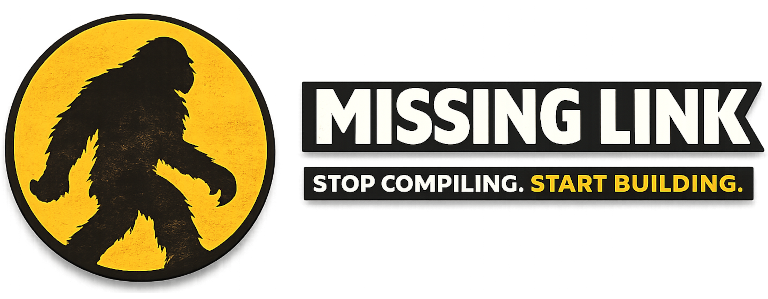

<div style="text-align:center;">
  
  <div style="margin-top:12px; font-size:16px;">
    <b>MissingLink Pre-Built Optimized  Colab Python wheels</b><br/>
    The ZImage GGUF Notebook demonstrates how even Free GPU Instances like T4 can be used for easy Image Generation using MissingLink wheels, saving you hours of configuration and time savings.
  </div>
</div>

Small GPU Instances like T4 struggle with large Image Generation models, luckily the community has built a number of models that are quantized ( lower quality ) that work on this scale.

This notebook demonstrates one of the more troublesome libraries stable_diffusion_cpp and how it lets you load gguf models easily.

*ZImage GGUF Image Generation MissingLink Notebook* lets you **Generate Beautiful 2D Images from text or image and text** ZImage is one of latest state of the art open source image generation models.

This notebook is designed to get you up and running in colab with zero configuration and zero headaches so you don't waste time and money.

1. [Get a Token](https://www.missinglink.build/pricing.html) by signing up for the free trial or purchase a bundle at https://www.missinglink.build this will let you download the optimized A100 Colab wheels. **Replace the ****** text with your token in the cell below.** ( see [Additional Purchase Options](https://www.missinglink.build/pricing.html)

2. **Connect to L4 or A100 Runtime ( Top Right of Colab UI )** you will need to buy credits to run these instances [Buy Colab Credits](https://colab.research.google.com/signup?utm_source=resource_tab&utm_medium=link&utm_campaign=payg_learn_more)

3. Click '**Run All**'

4. Generate an image!

**UI Coming Soon

*Don't waste your time worrying about configuration or waiting for compilation!*

In [5]:
import os
#MACHINE = "t4" Meant for a t4
os.environ['MISSING_LINK_TOKEN'] = "*****************************"
TOKEN = os.environ['MISSING_LINK_TOKEN']
!pip install --no-deps "https://{TOKEN}@missinglink.build/wheel/stable_diffusion_cpp_python-0.4.5-cp312-cp312-linux_x86_64.whl"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 MB 6.8 MB/s eta 0:00:00


In [6]:
import os
from huggingface_hub import hf_hub_download
from stable_diffusion_cpp import StableDiffusion
from PIL import Image

# --- Pick a quant (Q4_K_M is a good default on T4) ---
DIFF_REPO = "unsloth/Z-Image-Turbo-GGUF"
DIFF_FILE = "z-image-turbo-Q4_K_M.gguf"   # other options exist in the repo

# Required components for Z-Image GGUF inference (LLM + VAE)
LLM_REPO  = "unsloth/Qwen3-4B-Instruct-2507-GGUF" # Will run on T4
LLM_FILE  = "Qwen3-4B-Instruct-2507-Q4_K_M.gguf"
VAE_REPO  = "black-forest-labs/FLUX.1-schnell"
VAE_FILE  = "ae.safetensors"

# --- Download to local paths ---
diff_path = hf_hub_download(repo_id=DIFF_REPO, filename=DIFF_FILE)
llm_path  = hf_hub_download(repo_id=LLM_REPO,  filename=LLM_FILE)
vae_path  = hf_hub_download(repo_id=VAE_REPO,  filename=VAE_FILE)

print("Diffusion:", diff_path)
print("LLM      :", llm_path)
print("VAE      :", vae_path)

# --- Load (this is the "GGUF model load") ---
sd = StableDiffusion(
    diffusion_model_path=diff_path,
    llm_path=llm_path,
    vae_path=vae_path,
    # T4-friendly toggles:
    offload_params_to_cpu=True,     # safer on VRAM (uses more system RAM)
    diffusion_flash_attn=True,      # reduces memory / improves speed when supported
)

stable-diffusion.cpp:166  - Using CUDA backend
ggml_extend.hpp:78   - ggml_cuda_init: found 1 CUDA devices:


Diffusion: /root/.cache/huggingface/hub/models--unsloth--Z-Image-Turbo-GGUF/snapshots/6c80814333b7b6a70a2e5b469a7c6437ce65de0f/z-image-turbo-Q4_K_M.gguf
LLM      : /root/.cache/huggingface/hub/models--unsloth--Qwen3-4B-Instruct-2507-GGUF/snapshots/a06e946bb6b655725eafa393f4a9745d460374c9/Qwen3-4B-Instruct-2507-Q4_K_M.gguf
VAE      : /root/.cache/huggingface/hub/models--black-forest-labs--FLUX.1-schnell/snapshots/741f7c3ce8b383c54771c7003378a50191e9efe9/ae.safetensors


ggml_extend.hpp:78   -   Device 0: Tesla T4, compute capability 7.5, VMM: yes
stable-diffusion.cpp:260  - loading diffusion model from '/root/.cache/huggingface/hub/models--unsloth--Z-Image-Turbo-GGUF/snapshots/6c80814333b7b6a70a2e5b469a7c6437ce65de0f/z-image-turbo-Q4_K_M.gguf'
model.cpp:370  - load /root/.cache/huggingface/hub/models--unsloth--Z-Image-Turbo-GGUF/snapshots/6c80814333b7b6a70a2e5b469a7c6437ce65de0f/z-image-turbo-Q4_K_M.gguf using gguf format
model.cpp:416  - init from '/root/.cache/huggingface/hub/models--unsloth--Z-Image-Turbo-GGUF/snapshots/6c80814333b7b6a70a2e5b469a7c6437ce65de0f/z-image-turbo-Q4_K_M.gguf'
stable-diffusion.cpp:307  - loading llm from '/root/.cache/huggingface/hub/models--unsloth--Qwen3-4B-Instruct-2507-GGUF/snapshots/a06e946bb6b655725eafa393f4a9745d460374c9/Qwen3-4B-Instruct-2507-Q4_K_M.gguf'
model.cpp:370  - load /root/.cache/huggingface/hub/models--unsloth--Qwen3-4B-Instruct-2507-GGUF/snapshots/a06e946bb6b655725eafa393f4a9745d460374c9/Qwen3-4B-Instr

Generate an Image from Text with ZImage GGUF Models and stable_diffusion_cpp Flash Attention Painlessly in colab!

Change the prompt below to generate different images!

stable-diffusion.cpp:3493 - generate_image 768x768
stable-diffusion.cpp:3527 - sampling using Euler method
denoiser.hpp:494  - get_sigmas with discrete scheduler
stable-diffusion.cpp:3654 - TXT2IMG
conditioner.hpp:1718 - parse '<|im_start|>user
a cinematic photo of a sasquatch ape man looking at a GPU in the forest, ultra detailed, soft light<|im_end|>
<|im_start|>assistant
' to [['<|im_start|>user
', 1], ['a cinematic photo of a sasquatch ape man looking at a GPU in the forest, ultra detailed, soft light', 1], ['<|im_end|>
<|im_start|>assistant
', 1], ]
llm.hpp:259  - split prompt "<|im_start|>user
" to tokens ["<|im_start|>", "user", "Ċ", ]
llm.hpp:259  - split prompt "a cinematic photo of a sasquatch ape man looking at a GPU in the forest, ultra detailed, soft light" to tokens ["a", "Ġcinematic", "Ġphoto", "Ġof", "Ġa", "Ġs", "as", "qu", "atch", "Ġape", "Ġman", "Ġlooking", "Ġat", "Ġa", "ĠGPU", "Ġin", "Ġthe", "Ġforest", ",", "Ġultra", "Ġdetailed", ",", "Ġsoft", "Ġlight", ]
llm.hpp:259

System Info: 
    SSE3 = 1 |     AVX = 1 |     AVX2 = 1 |     AVX512 = 1 |     AVX512_VBMI = 0 |     AVX512_VNNI = 1 |     FMA = 1 |     NEON = 0 |     ARM_FMA = 0 |     F16C = 1 |     FP16_VA = 0 |     WASM_SIMD = 0 |     VSX = 0 | 


ggml_extend.hpp:1857 - qwen3 offload params (3555.38 MB, 398 tensors) to runtime backend (CUDA0), taking 1.07s
ggml_extend.hpp:1759 - qwen3 compute buffer size: 3.50 MB(VRAM)
conditioner.hpp:1962 - computing condition graph completed, taking 1328 ms
stable-diffusion.cpp:3271 - get_learned_condition completed, taking 1335 ms
stable-diffusion.cpp:3382 - generating image: 1/1 - seed 0
ggml_extend.hpp:1857 - z_image offload params (4786.65 MB, 453 tensors) to runtime backend (CUDA0), taking 1.19s
ggml_extend.hpp:1759 - z_image compute buffer size: 299.31 MB(VRAM)
stable-diffusion.cpp:3424 - sampling completed, taking 25.01s
stable-diffusion.cpp:3435 - generating 1 latent images completed, taking 25.01s
stable-diffusion.cpp:3438 - decoding 1 latents
ggml_extend.hpp:1857 - vae offload params (160.00 MB, 244 tensors) to runtime backend (CUDA0), taking 0.14s
ggml_extend.hpp:1759 - vae compute buffer size: 3744.56 MB(VRAM)
stable-diffusion.cpp:2700 - computing vae decode graph completed, taking

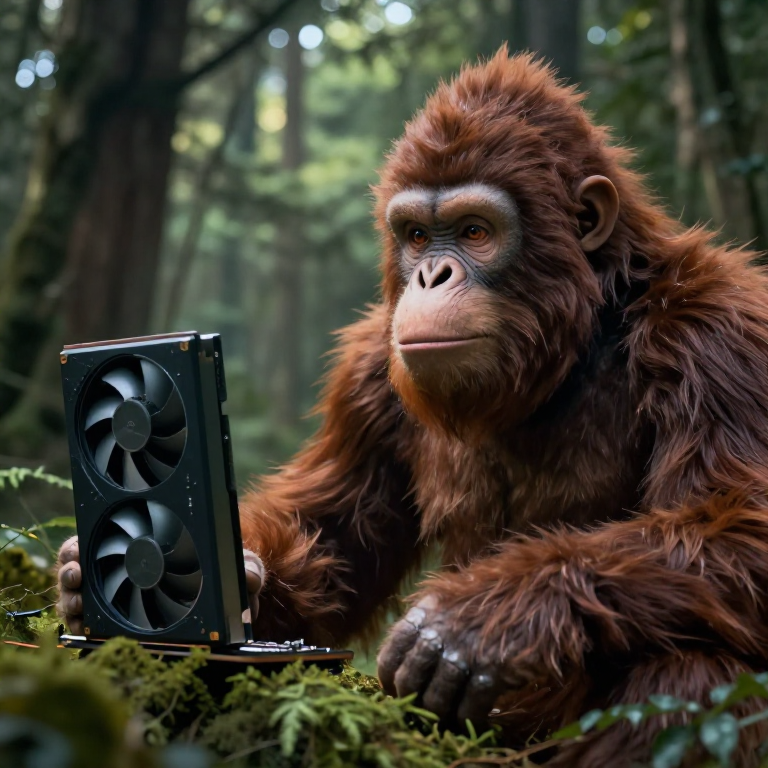

In [7]:
prompt = "a cinematic photo of a sasquatch ape man looking at a GPU in the forest, ultra detailed, soft light"

out = sd.generate_image(
    prompt=prompt,
    width=768,
    height=768,
    sample_steps=8,
    cfg_scale=1.0,
    sample_method="euler",
    seed=0,
)

# out is a PIL Image in recent versions; if you get a list, take out[0]
img = out[0] if isinstance(out, (list, tuple)) else out
display(img)